# 📊 Customer Behavior Analysis – Telco Dataset

## 🧩 Problem Statement

Las empresas de telecomunicaciones enfrentan altos niveles de cancelación de clientes (*churn*), lo que impacta directamente sus ingresos.
El objetivo de este análisis es identificar patrones de comportamiento que expliquen **qué tipo de clientes abandonan el servicio y por qué**.

---

## 🔍 Key Questions

* ¿Qué métodos de pago están asociados a mayor churn?
* ¿Qué tipo de clientes generan más ingresos?
* ¿Existe relación entre método de pago, nivel de compromiso y permanencia?




In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pl = pd.read_csv("Telco-Customer-Churn.csv")
#Sacamos una pequeña muestra del datset para su evaluación
pl.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**📁Data Understanding**

The dataset contains 7043 customers and 21 features, including demographic information, services subscribed, and billing details.

In [2]:
#validamos la cantidad de filas y columnas
pl.shape

(7043, 21)

In [3]:
#Revisamos los tipos de datos y detectamos posibles problemas como columnas mal tipadas o valores nulos
pl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
#Evaluamos la cantidad de clientes que se han ido y la cantidad que ha permanecido
pl['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [30]:
# Presentamos la información de forma poncentual
#Aproximadamente el 26.5% de los clientes abandona el servicio, lo que representa una tasa significativa de churn que puede impactar los ingresos de la empresa.
pl['Churn'].value_counts(normalize = True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [18]:
#Verificamos la presencia de valores nulos para identificar posibles problemas en la calidad de los datos
pl.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
pl.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [27]:
tabla2 = pl.groupby("Contract")["Churn"].value_counts(normalize = True).unstack()*100
tabla2 = tabla2.rename(columns = {"No" : "No canceló", "Yes" : "canceló"}).rename_axis("Estado del servicio:" , axis = "columns")
tabla2.round(2).astype(str) + "%"

Estado del servicio:,No canceló,canceló
Contract,,
Month-to-month,57.29%,42.71%
One year,88.73%,11.27%
Two year,97.17%,2.83%


<Axes: xlabel='Contract'>

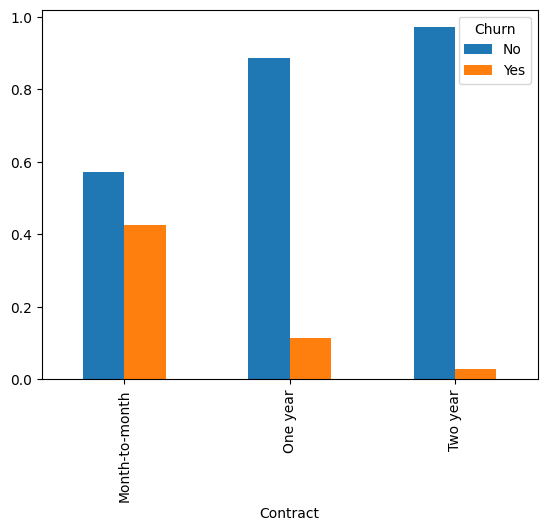

In [33]:
pl.groupby("Contract")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar")

Los clientes con contratos month-to-month presentan una tasa de churn significativamente más alta (42.7%) en comparación con contratos de un año (11.3%) y dos años (2.8%).
Esto evidencia que el nivel de compromiso contractual es uno de los factores más determinantes en la retención de clientes.
    

In [36]:
pl.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

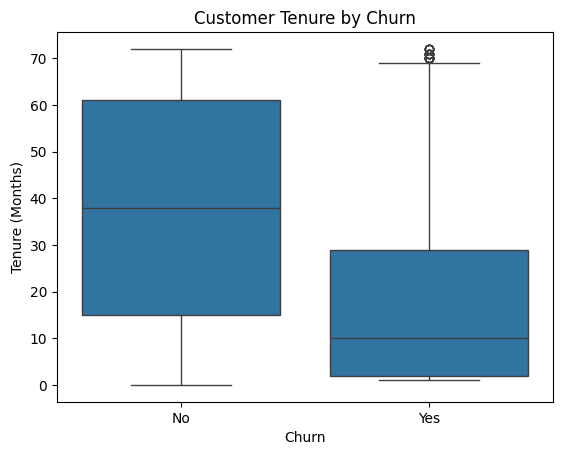

In [43]:
sns.boxplot(x="Churn", y="tenure", data=pl)

plt.title("Customer Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

Los clientes que abandonan el servicio tienen una antigüedad promedio de 17.9 meses, mientras que los que permanecen alcanzan 37.5 meses.
Esto indica que el riesgo de cancelación es considerablemente mayor en las primeras etapas del ciclo de vida del cliente.

In [37]:
pl.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

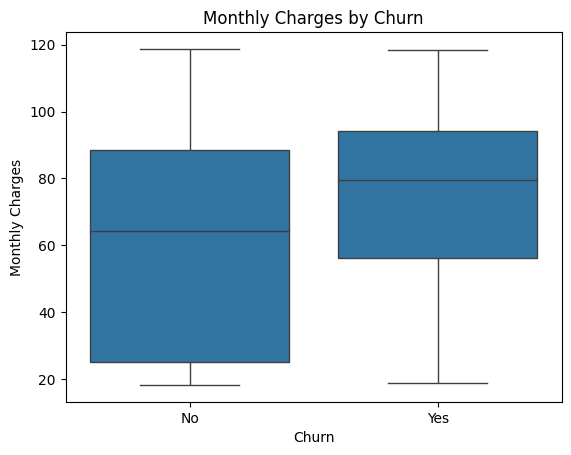

In [45]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=pl)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Los clientes que cancelan el servicio presentan un gasto mensual promedio mayor (74.4) que aquellos que permanecen (61.2), lo que indica que el churn no está impulsado por bajo valor del cliente, sino posiblemente por una percepción de desbalance entre costo y valor recibido.

In [19]:
tabla3 = pl[ "PaymentMethod"].value_counts(normalize = True)* 100
tabla3 

PaymentMethod
Electronic check             33.579441
Mailed check                 22.887974
Bank transfer (automatic)    21.922476
Credit card (automatic)      21.610109
Name: proportion, dtype: float64

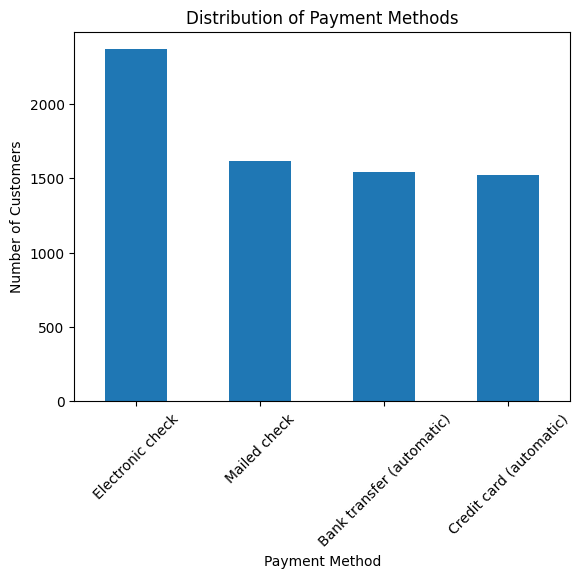

In [46]:
pl["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

El método de pago más utilizado es electronic check (33.6%), lo que lo convierte en el canal dominante dentro de la base de clientes. Sin embargo, su alta adopción debe analizarse en conjunto con otras variables como churn y tipo de contrato para entender su impacto real en la retención.

In [14]:
pl.groupby("PaymentMethod")["MonthlyCharges"].mean()

PaymentMethod
Bank transfer (automatic)    67.192649
Credit card (automatic)      66.512385
Electronic check             76.255814
Mailed check                 43.917060
Name: MonthlyCharges, dtype: float64

Los clientes que utilizan electronic check presentan el mayor gasto mensual promedio, lo que sugiere que este método está asociado a clientes de mayor valor inicial. No obstante, al tratarse de un método no automatizado, puede implicar menor compromiso y mayor facilidad de cancelación, lo que lo convierte en un segmento crítico a gestionar.

In [16]:
pl.groupby("PaymentMethod")["tenure"].mean()

PaymentMethod
Bank transfer (automatic)    43.656736
Credit card (automatic)      43.269382
Electronic check             25.174630
Mailed check                 21.830025
Name: tenure, dtype: float64

Los clientes que utilizan electronic check presentan una menor antigüedad promedio (~25 meses) en comparación con métodos automáticos (~43 meses), lo que indica una menor retención y menor estabilidad en este segmento.

In [24]:
pl.groupby("Contract")["PaymentMethod"].value_counts(normalize = True).unstack()*100

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,15.200000,14.012903,47.741935,23.045161
One year,26.544467,27.019688,23.557366,22.878479
Two year,33.274336,34.277286,9.911504,22.536873


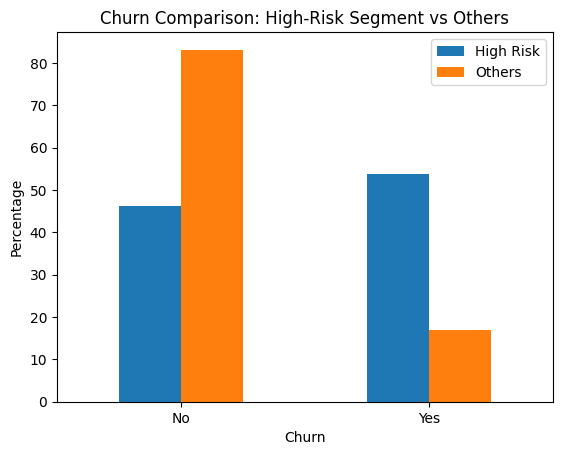

In [47]:
alto_riesgo = pl[
    (pl["Contract"] == "Month-to-month") &
    (pl["PaymentMethod"] == "Electronic check")
]

resto = pl.drop(alto_riesgo.index)

comparacion = pd.DataFrame({
    "High Risk": alto_riesgo["Churn"].value_counts(normalize=True),
    "Others": resto["Churn"].value_counts(normalize=True)
}) * 100

comparacion.plot(kind="bar")

plt.title("Churn Comparison: High-Risk Segment vs Others")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

Los clientes con contratos month-to-month utilizan predominantemente electronic check (~47.7%), mientras que los contratos de mayor duración presentan una mayor adopción de métodos de pago automáticos

In [28]:
tabla3 = pl.groupby(["Contract", "PaymentMethod"])["Churn"].value_counts(normalize=True).unstack()*100
tabla3.rename(columns = {"No" : "No canceló", "Yes" : "canceló"}).rename_axis("Estado del servicio:" , axis = "columns")
tabla3.round(2).astype(str) + "%"

Churn                                         No     Yes
Contract       PaymentMethod                            
Month-to-month Bank transfer (automatic)  65.87%  34.13%
               Credit card (automatic)    67.22%  32.78%
               Electronic check           46.27%  53.73%
               Mailed check               68.42%  31.58%
One year       Bank transfer (automatic)  90.28%   9.72%
               Credit card (automatic)     89.7%   10.3%
               Electronic check           81.56%  18.44%
               Mailed check               93.18%   6.82%
Two year       Bank transfer (automatic)  96.63%   3.37%
               Credit card (automatic)    97.76%   2.24%
               Electronic check           92.26%   7.74%
               Mailed check               99.21%   0.79%

El método de pago con mayor tasa de churn en todos los tipos de contrato es el electronic check, alcanzando más del 50% en contratos mensuales, lo que sugiere que este método está fuertemente asociado con clientes de alto riesgo de cancelación.




## 📈 Key Findings

### 1. Electronic Check: alto ingreso, baja retención

Se identificó que los clientes que utilizan **electronic check** presentan:

* 💰 El mayor gasto mensual promedio
* 📉 La mayor tasa de churn
* ⏳ Menor tiempo de permanencia (*tenure*)

👉 Esto indica que:

> Son clientes de alto valor inicial, pero con bajo compromiso a largo plazo.

---

### 2. Métodos automáticos: estabilidad y retención

Los clientes que utilizan:

* Tarjeta de crédito (automático)
* Transferencia bancaria (automática)

Presentan:

* 📉 Menor churn
* ⏳ Mayor permanencia
* 🔁 Comportamiento más estable

👉 Esto sugiere que:

> La automatización del pago está directamente relacionada con la retención del cliente.

---

### 3. Contratos mensuales: foco de riesgo

Se observó que:

* Los clientes con contratos **month-to-month**
* Utilizan en mayor proporción **electronic check**
* Y presentan mayor churn

👉 Esto revela un patrón crítico:

> Bajo compromiso + pagos no automatizados = alta probabilidad de abandono

---

## 🧠 Customer Segmentation

A partir del análisis, se identificaron tres perfiles principales:

* 🔴 **Cliente de bajo compromiso**
  (Electronic check + contrato mensual + alto churn)

* 🟢 **Cliente estable**
  (Pagos automáticos + contratos largos + baja tasa de churn)

* 🟡 **Cliente tradicional**
  (Mailed check + menor adopción digital)

---

## 🚀 Business Recommendations

### 1. Incentivar pagos automáticos

* Descuentos por activar autopay
* Beneficios exclusivos

---

### 2. Migrar clientes de alto riesgo

* Enfocar estrategias en usuarios de electronic check
* Promover transición hacia métodos automáticos

---

### 3. Aumentar compromiso contractual

* Incentivar contratos de mayor duración
* Ofrecer mejores condiciones a largo plazo

---

## 💡 Final Insight

> Los métodos de pago no solo reflejan una preferencia operativa, sino el nivel de compromiso del cliente.
> Aquellos con menor fricción de salida (pagos manuales) presentan mayores tasas de abandono, incluso cuando generan mayores ingresos iniciales.
> Este hallazgo sugiere que estrategias enfocadas en la migración hacia pagos automáticos y contratos de mayor duración pueden tener un impacto directo en la reducción del churn y el incremento del valor de vida del cliente..

---

## 🏁 Conclusion

Este análisis demuestra que la retención no depende únicamente del valor económico del cliente, sino de su comportamiento y nivel de compromiso.
Optimizar la experiencia de pago puede ser una de las estrategias más efectivas para reducir el churn y aumentar el valor de vida del cliente.
